# Chapter 4. Training Models

Having a good understanding of how ML algorithms work can help 
- Quickly home in on the appropriate model, the right trainining algorithms to use, and a good set of hyperparameters for your task
- Debug issues and perform error analysis more efficiently
- Is essential in understanding, building, and training neural networks.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import add_dummy_feature, PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import learning_curve, train_test_split, KFold, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_iris
from sklearn.metrics import precision_score, recall_score, f1_score

## 1 Linear Regression

A linear model makes a prediction by simplying computing a weighted sum of the input features, plus a constant (*bias* term/*intercept* term).


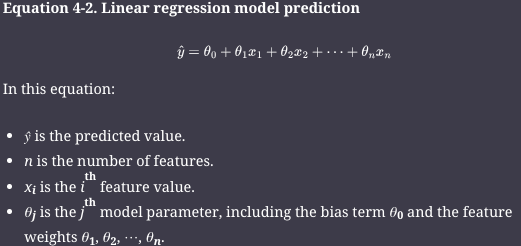
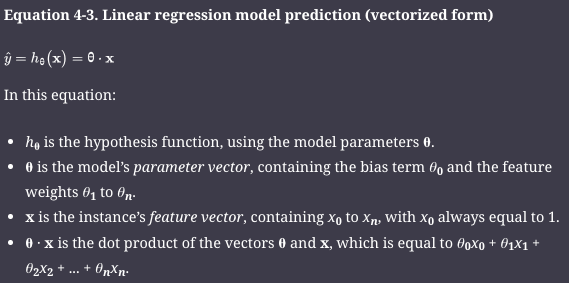

Learning algorithms will often optimize a different loss function during training than the performance measure used to evaluate the final model. This is generally because the function is easier to optimize and/or because it has extra terms needed during training only (e.g., for regularization). A good training loss is easy to optimize and straongly correlated with the metric. For example, classifiers are often trained using a cost function such as the log loss, but evaluated using precision/recall. The log loss is easy to minimize, and doing so will usually improve precision/recall.

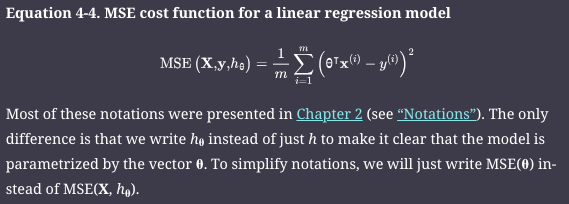

### 1.1. The Normal Equation

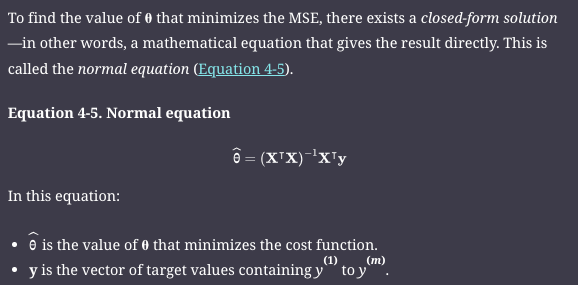

In [2]:
rng = np.random.default_rng(seed = 316)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

Text(0, 0.5, 'y')

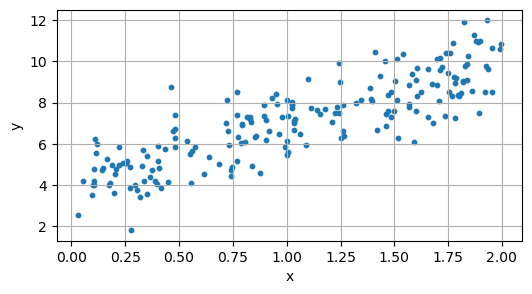

In [3]:
fig, ax = plt.subplots(figsize = (6,3))
ax.scatter(X, y, s=10)
ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")

In [4]:
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.99190769],
       [2.98928424]])

In [5]:
print(np.linalg.inv(X_b.T @ X_b).shape)
print(X_b.T.shape)
print(y.shape)

(2, 2)
(2, 200)
(200, 1)


In [6]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
X_new_b @ theta_best

array([[3.99190769],
       [9.97047617]])

Text(0, 0.5, 'y')

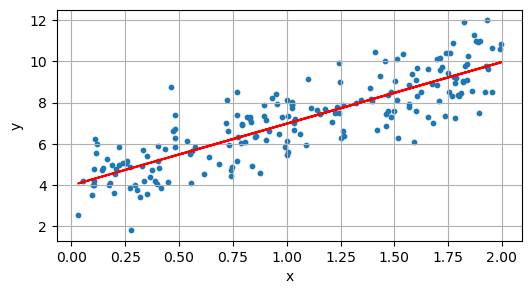

In [7]:
y_pred = X_b @ theta_best
fig, ax = plt.subplots(figsize = (6,3))
ax.plot(X, y_pred, 'r-')
ax.scatter(X, y, s=10)
ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")

Scikit-Learn uses SVD approach.

In [8]:
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_svd = linear_model.predict(X_new)
print(linear_model.intercept_, linear_model.coef_)

[3.99190769] [[2.98928424]]


### 1.2. Computational Complexity

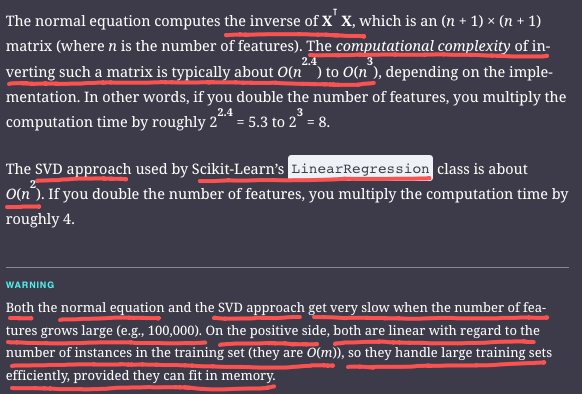

## 2. Gradient Descent

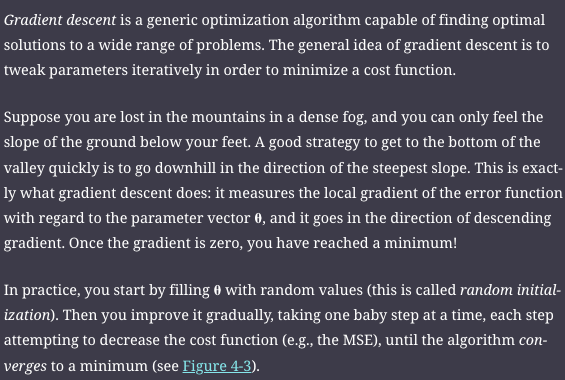
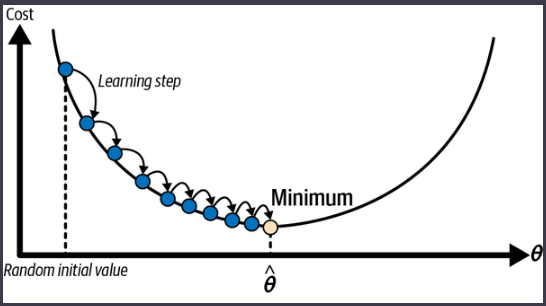
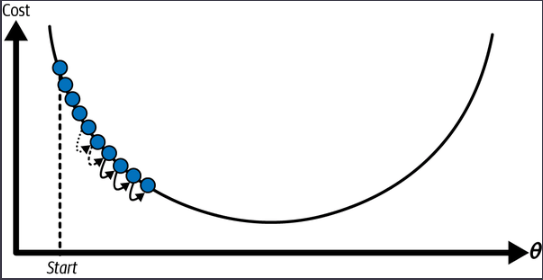
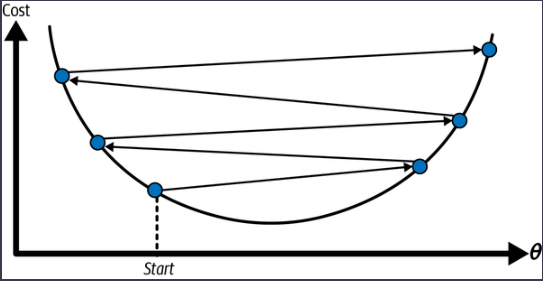
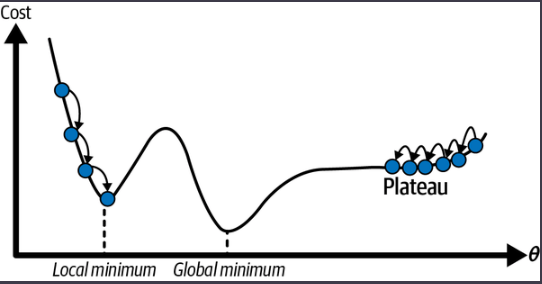

Warning: when using gradient descent, we should ensure that <span style="color: #e74c3c;">all features have a similar scale</span> (e.g., using `StandardScaler` class), or else it will take much longer to converge

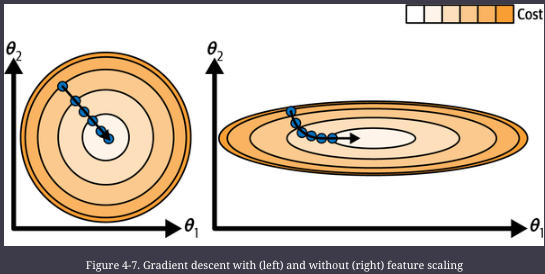

### 2.1. Batch Gradient Descent

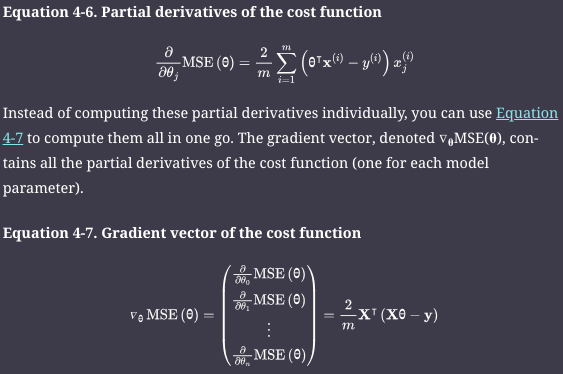
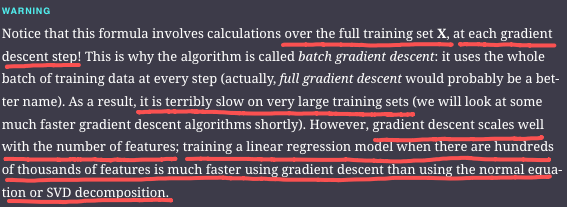
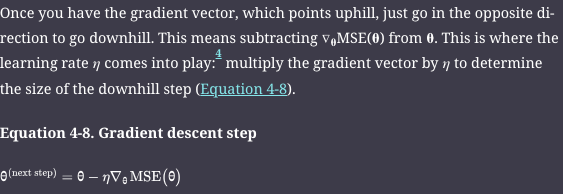
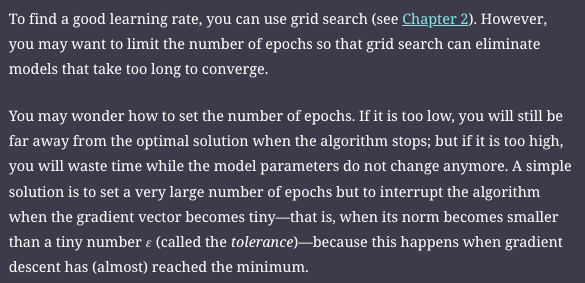

### 2.2. Stochastic Gradiant Descent

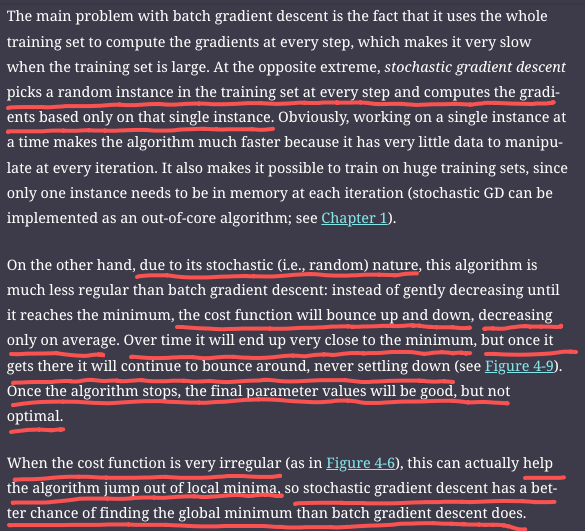
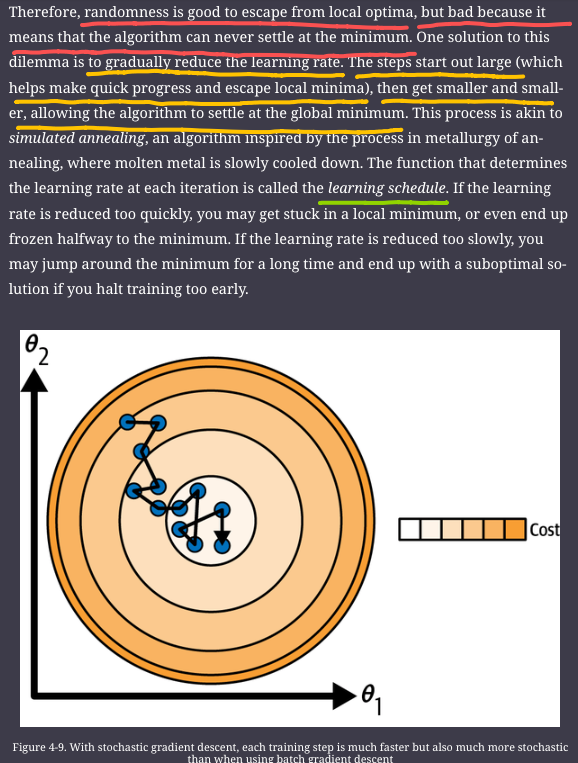
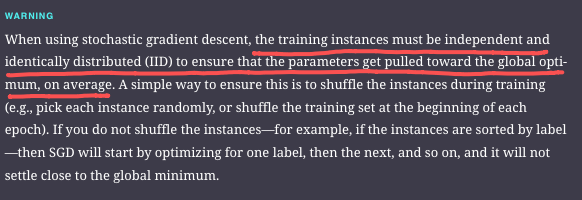

In [9]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters
m = len(X_b)

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=316)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

print(theta)

[[4.00122605]
 [2.99661864]]


In [10]:
sgd_reg = SGDRegressor(tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=316)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([3.99130486]), array([2.98978439]))

***Stochastic Gradient Descent (SGD)*** updates model parameters using **one randomly sampled observation at a time**. **Each individual update is called a step, and one epoch consists of m steps (where m is the training set size) — meaning within each epoch, the algorithm performs m random draws and m parameter updates. Training typically runs for multiple epochs (e.g., 50), resulting in 50 × m total steps**. 
<br>

Compared to Batch GD, SGD is faster per update, supports out-of-core training, and its inherent noise can help escape local minima — though a decaying learning rate is recommended so the parameters gradually settle near the minimum rather than bouncing around indefinitely.

### 2.3. Mini-Batch Gradient Descent

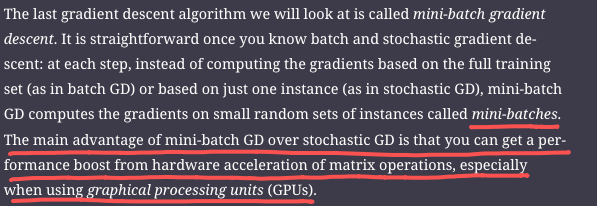

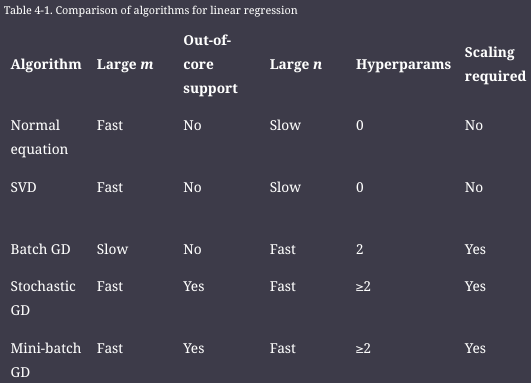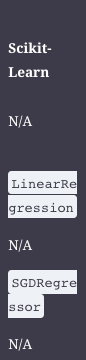

There is almost no difference after training: all these algorithms end up with very similar models and make predictions in exactly the same way.

## 3. Polynomial Regression

In [12]:
rng = np.random.default_rng(seed=32)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

In [16]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.2521835]), array([[1.00887989, 0.43901411]]))

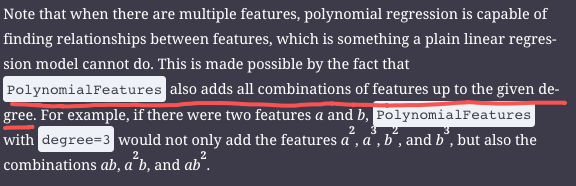
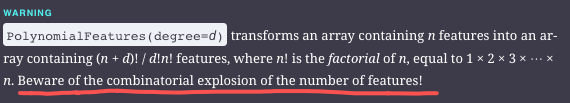

## 4. Learning Curves

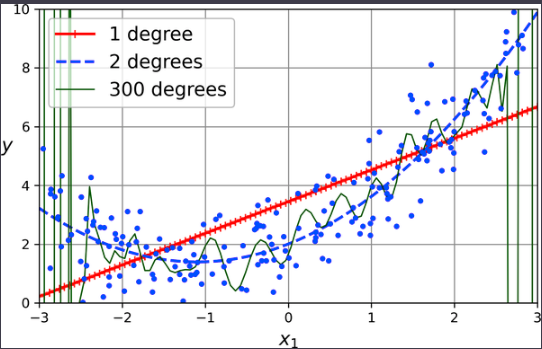

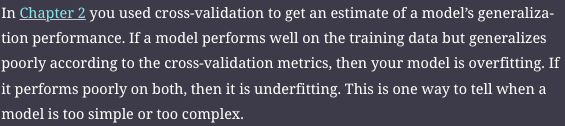
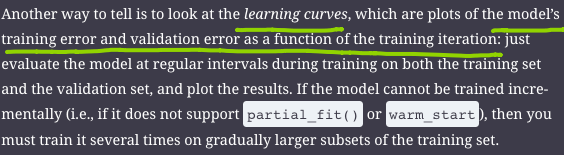

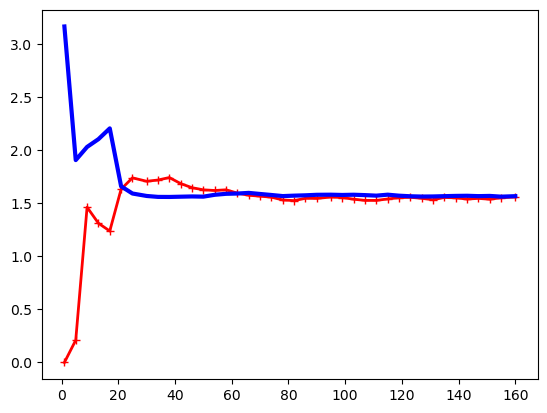

In [ ]:
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

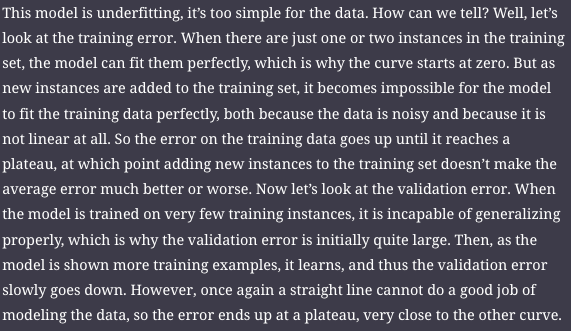
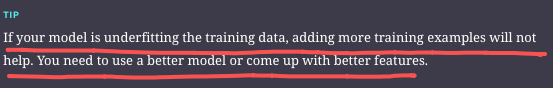

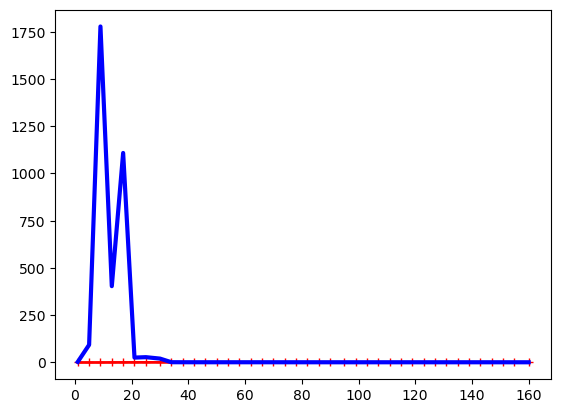

In [41]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

There is a gap between the curves, indicating that the model performs better on the training data than on the validation data, which is the hallmark of an overfitting model. **If we use a much larger training set, the two curves would continue to get closer**

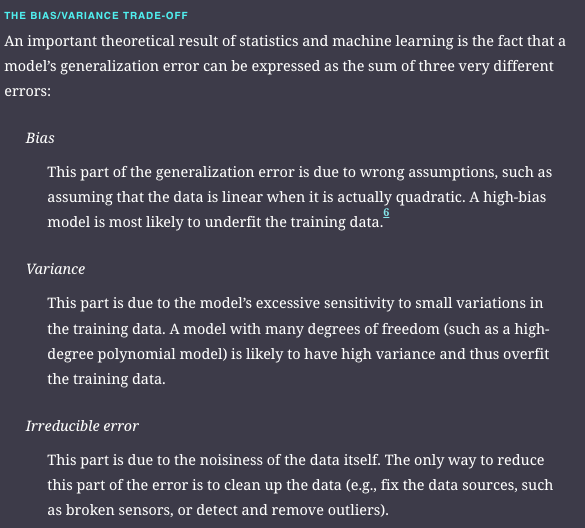
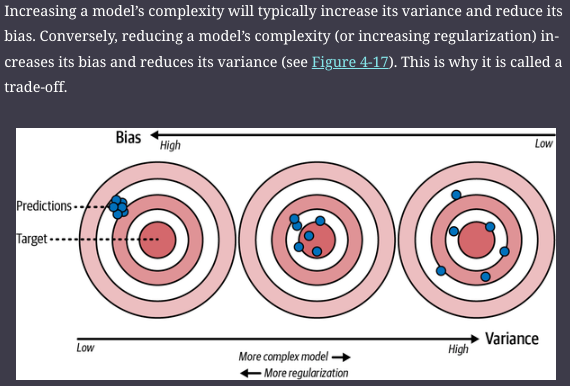

## 5. Regularized Linear Models

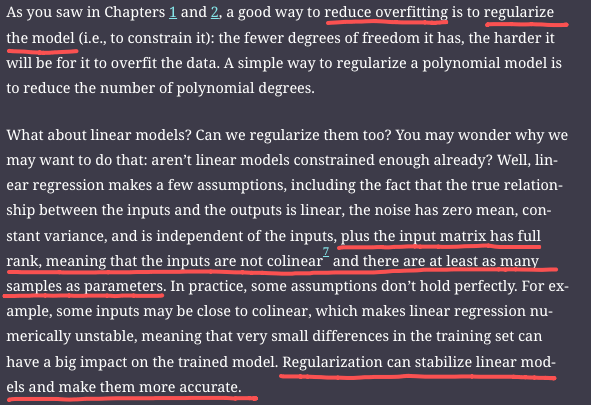

### 5.1. Ridge Regression

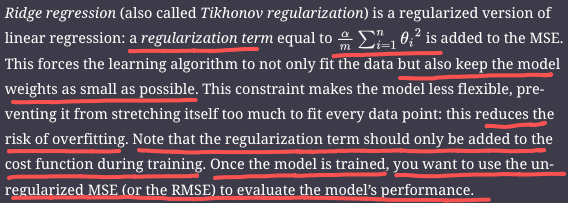
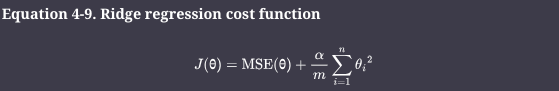
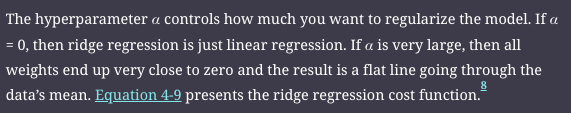
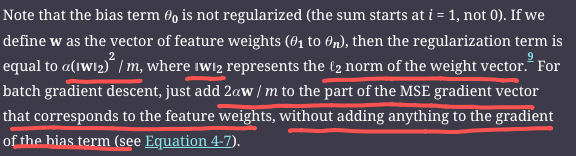

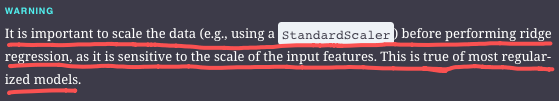

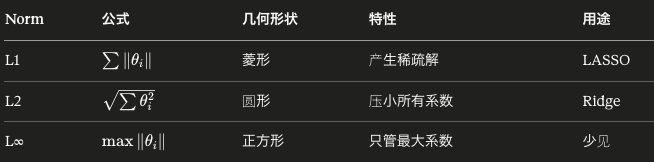
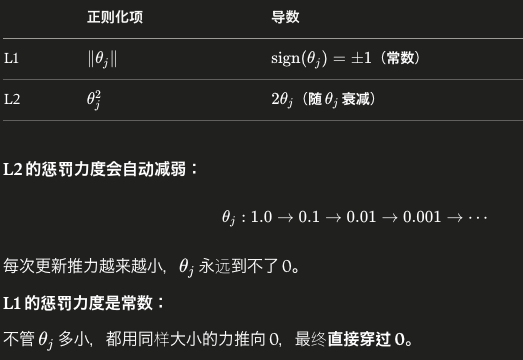

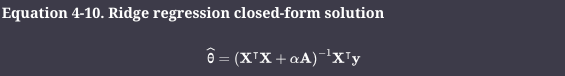

where A is the (n + 1) × (n + 1) identity matrix, except with a 0 in the top-left cell, corresponding to the bias term.

In [52]:
ridge_reg = Ridge(alpha=0.1)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.14814234])

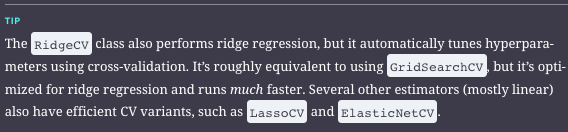

### 5.2. Lasso Regression

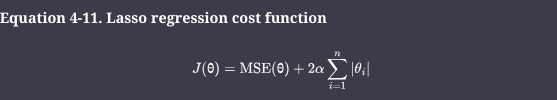
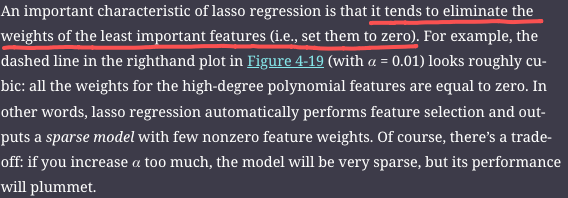

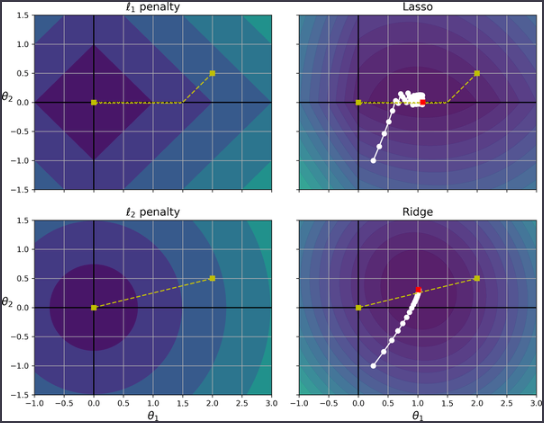

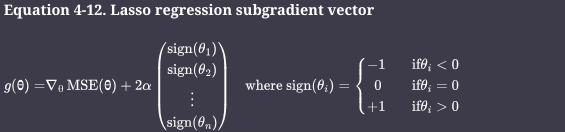
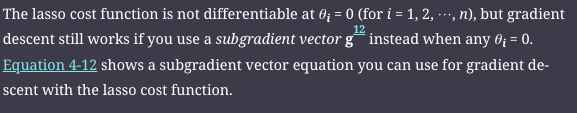

In [56]:
lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.09614622])

### 5.3. Elastic Net Regression

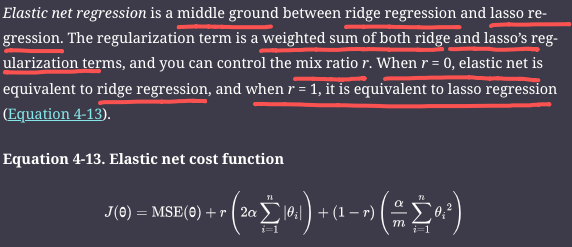
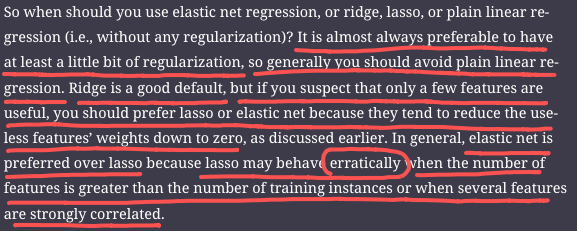

In [58]:
elastic_net_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net_reg.fit(X, y)
elastic_net_reg.predict([[1.5]])

array([5.09688623])

### 5.4. Early Stopping

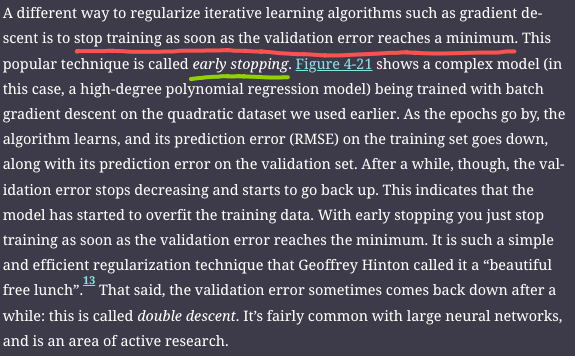
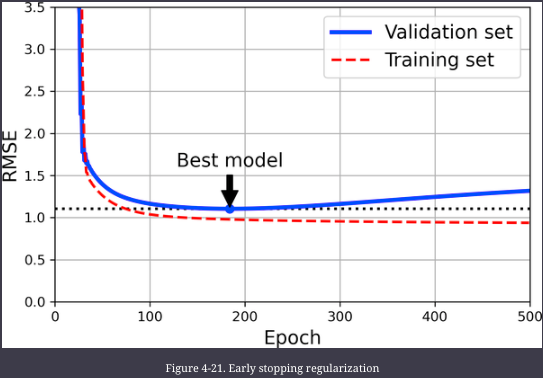

## 6. Logistic Regression

### 6.1. Estimating Probabilities

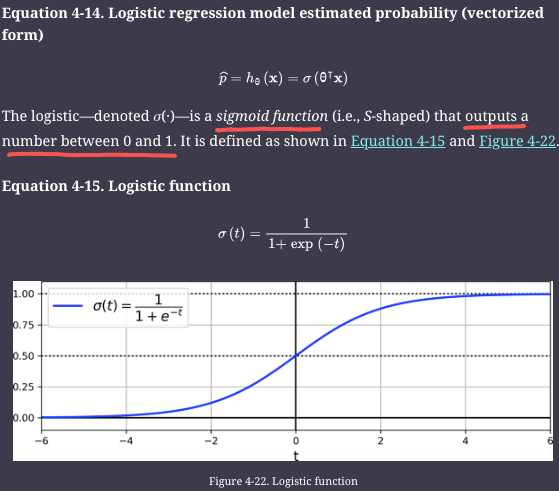
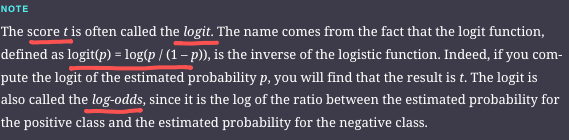
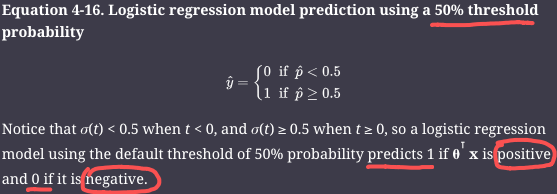

### 6.2. Training and Cost Function

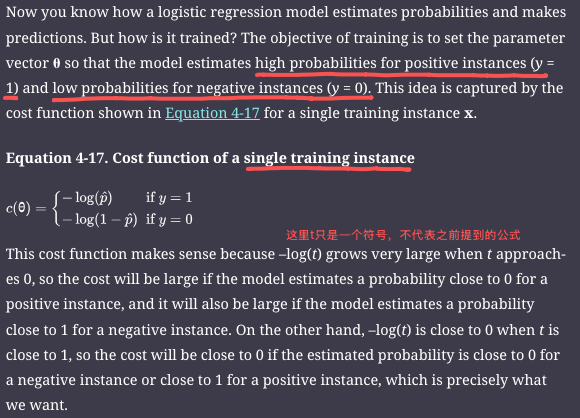
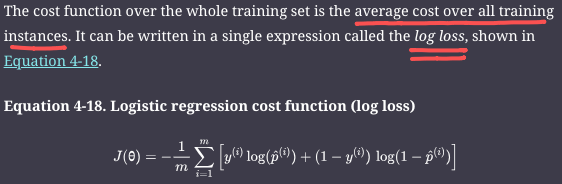
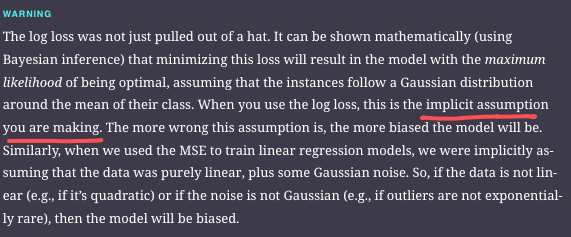
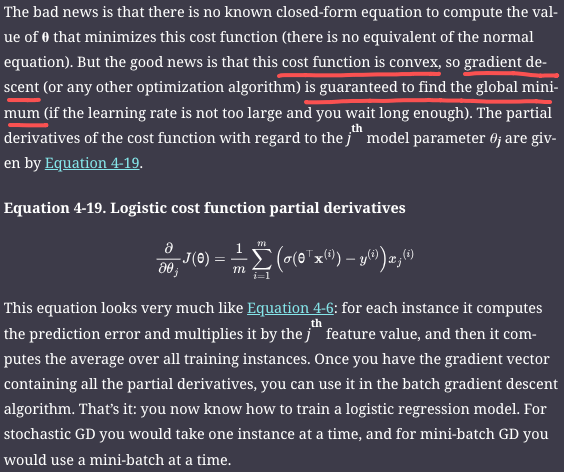

### 6.3. Decision Boundaries

In [7]:
iris = load_iris(as_frame=True)
iris.data.info()
iris.data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
iris.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [60]:
X_train, X_test, y_train, y_test = train_test_split(iris.data[["petal width (cm)"]].values, 
                                                    iris.target_names[iris.target] == 'virginica', 
                                                    test_size=0.25, random_state=316)
logistic_reg = LogisticRegression()
logistic_reg.fit(X_train, y_train)

LogisticRegression()

In [70]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = logistic_reg.predict_proba(X_new)
logistic_reg.classes_

array([False,  True])

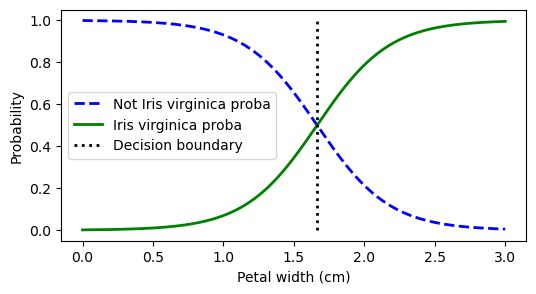

In [74]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = logistic_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

fig, ax = plt.subplots(figsize = (6,3))
ax.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
ax.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
ax.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")
ax.set_xlabel("Petal width (cm)")
ax.set_ylabel("Probability")
ax.legend()
plt.show()

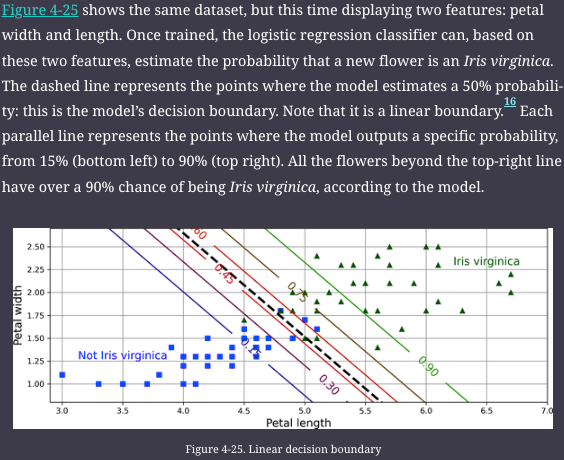

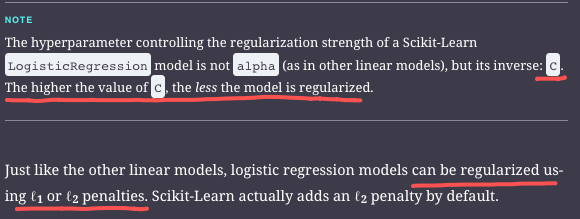

### 6.4. Softmax Regression